# Construcción y almacenamiento de clústers municipales

**Objetivo:** construir clústers climáticos a escala municipal, validarlos y guardar el archivo `clusters_municipales.csv` en `data/processed`.

Este notebook parte del archivo `features_intra_anuales_2007-2024.csv`, que ya contiene variables climáticas agregadas, variables intra-anuales, extremos, anomalías y `MpAltitud`.


In [1]:
# Librerías
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 1. Rutas del proyecto

In [2]:
# Raíz del proyecto y carpeta de datos procesados
PROJECT_ROOT = Path().resolve().parents[1]
path = PROJECT_ROOT / "data" / "processed"

archivo_features = path / "features_intra_anuales_2007-2024.csv"
archivo_clusters = path / "clusters_municipales.csv"
archivo_features_cluster = path / "features_intra_anuales_2007-2024_con_clusters.csv"

print("Directorio processed:", path)
print("Archivo features:", archivo_features)


Directorio processed: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed
Archivo features: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/features_intra_anuales_2007-2024.csv


## 2. Cargar base de features intra-anuales

La base puede venir con `municipio` como columna o como índice. Por eso se carga y se valida de forma flexible.


In [3]:
# Cargar archivo
if not archivo_features.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_features}")

# Lectura inicial conservando todas las columnas visibles
df_model = pd.read_csv(archivo_features)

# Si hay columnas sin nombre típicas de índices guardados en CSV, se renombran o eliminan según el caso
unnamed_cols = [c for c in df_model.columns if str(c).startswith("Unnamed")]

# Caso común: municipio quedó guardado como índice sin nombre o como primera columna Unnamed: 0
if "municipio" not in df_model.columns and unnamed_cols:
    first_unnamed = unnamed_cols[0]
    # Si la columna no parece un simple índice numérico, probablemente contiene municipio
    if df_model[first_unnamed].dtype == "object":
        df_model = df_model.rename(columns={first_unnamed: "municipio"})
    else:
        df_model = df_model.drop(columns=unnamed_cols)

# Segundo intento: leer usando primera columna como índice y recuperar el índice
if "municipio" not in df_model.columns:
    df_tmp = pd.read_csv(archivo_features, index_col=0)
    df_tmp = df_tmp.reset_index()
    if "municipio" in df_tmp.columns:
        df_model = df_tmp.copy()
    elif "index" in df_tmp.columns and df_tmp["index"].dtype == "object":
        df_model = df_tmp.rename(columns={"index": "municipio"})

# Validación final de municipio
if "municipio" not in df_model.columns:
    raise ValueError(
        "No se encontró la columna 'municipio'. Revisa si el archivo features fue guardado "
        "sin conservar la dimensión municipal. Debe existir una columna o índice con el municipio."
    )

# Limpieza básica
df_model["municipio"] = df_model["municipio"].astype(str).str.strip()

print("Dimensiones df_model:", df_model.shape)
print("Número de municipios:", df_model["municipio"].nunique())
df_model.head()


Dimensiones df_model: (450, 504)
Número de municipios: 25


,municipio,date,anio,Área sembrada (ha),Rendimiento (t/ha),produccion_t,precip_mm_sum,precip_mm_mean,precip_mm_std,precip_mm_min,...,ndvi_max_z_max_anual,balance_hidrico_mm_z_mean_anual,balance_hidrico_mm_z_min_anual,balance_hidrico_mm_z_max_anual,deficit_hidrico_mm_z_mean_anual,deficit_hidrico_mm_z_min_anual,deficit_hidrico_mm_z_max_anual,exceso_hidrico_mm_z_mean_anual,exceso_hidrico_mm_z_min_anual,exceso_hidrico_mm_z_max_anual
0,Aguadas,2007-12-31,2007,4626.0,0.97,4063.0,2660.352575,221.696048,106.472932,39.417551,...,0.593546,0.343023,-1.319420,1.425035,0.131243,-0.618179,3.480916,0.361895,-1.220112,1.425035
1,Anserma,2007-12-31,2007,7125.0,1.30,7131.0,2168.859973,180.738331,79.863766,26.391460,...,0.840267,0.167279,-1.394092,1.550450,0.116148,-0.664257,3.258719,0.174870,-1.054646,1.550450
2,Aranzazu,2007-12-31,2007,2597.0,1.01,2254.0,2106.546668,175.545556,91.258936,35.359744,...,0.708279,0.170433,-1.729506,1.957977,0.527726,-0.761310,3.874084,0.227237,-1.051529,1.934536
3,Belalcázar,2007-12-31,2007,3734.0,1.20,3835.0,2429.582959,202.465247,85.739394,37.993671,...,0.809190,0.300368,-1.070850,1.321184,0.093395,-0.684778,3.236328,0.293302,-0.995501,1.367424
4,Chinchiná,2007-12-31,2007,5632.0,1.63,9203.0,2530.997565,210.916464,83.768437,58.426388,...,0.739713,0.109842,-1.212987,1.222853,0.264114,-0.529252,3.675252,0.115842,-1.208808,1.262900


## 3. Variables estructurales para clusterización

Para clústers municipales conviene usar variables **estructurales y estables**, no todas las features derivadas. El objetivo es representar regímenes climáticos base por municipio.


In [4]:
# Variables recomendadas para clustering municipal
vars_clima = [
    "precip_mm_mean",             # precipitación media mensual/anual agregada
    "temp_mean_mean",             # temperatura media
    "et_real_mm_mean",            # evapotranspiración real media
    "ndvi_mean_mean",             # estado vegetativo promedio
    "balance_hidrico_mm_mean",    # balance hídrico medio
    "MpAltitud"                   # estructura espacial
]

faltantes = [c for c in vars_clima if c not in df_model.columns]
if faltantes:
    raise ValueError(f"Faltan variables para clusterización: {faltantes}")

print("Variables disponibles para clustering:")
print(vars_clima)


Variables disponibles para clustering:
['precip_mm_mean', 'temp_mean_mean', 'et_real_mm_mean', 'ndvi_mean_mean', 'balance_hidrico_mm_mean', 'MpAltitud']


## 4. Agregación a escala municipal

Cada municipio queda representado por el promedio histórico de sus variables estructurales.


In [5]:
# Agregar a nivel municipal
df_mun = (
    df_model
    .groupby("municipio", as_index=False)[vars_clima]
    .mean()
)

# Validación de datos faltantes
na_por_var = df_mun[vars_clima].isna().sum()
print("Valores faltantes por variable:")
print(na_por_var)

if na_por_var.sum() > 0:
    raise ValueError("Existen valores faltantes en las variables de clustering. Revisa df_mun antes de continuar.")

print("Dimensiones df_mun:", df_mun.shape)
df_mun.head()


Valores faltantes por variable:
precip_mm_mean             0
temp_mean_mean             0
et_real_mm_mean            0
ndvi_mean_mean             0
balance_hidrico_mm_mean    0
MpAltitud                  0
dtype: int64
Dimensiones df_mun: (25, 7)


,municipio,precip_mm_mean,temp_mean_mean,et_real_mm_mean,ndvi_mean_mean,balance_hidrico_mm_mean,MpAltitud
0,Aguadas,200.853095,17.591599,92.042603,0.698400,108.810493,2181.0
1,Anserma,178.126433,18.194710,98.333202,0.703205,79.793231,1765.0
2,Aranzazu,170.304235,15.266344,85.919687,0.593390,84.384548,1908.0
3,Belalcázar,188.966037,18.101458,98.516938,0.723399,90.449099,1600.0
4,Chinchiná,211.876215,17.318127,97.775746,0.730072,114.100469,1378.0


## 5. Optimización del número de clústers

Se evalúa `k` entre 2 y 6 usando Silhouette e inercia. Además se controla que los grupos no queden con un solo municipio, salvo que no exista alternativa.


In [6]:
# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_mun[vars_clima])

# Rango de k posible
n_municipios = df_mun.shape[0]
max_k = min(6, n_municipios - 1)
K_range = range(2, max_k + 1)

resultados_k = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts().sort_index()
    sil = silhouette_score(X_scaled, labels)
    inertia = kmeans.inertia_
    min_cluster_size = counts.min()
    resultados_k.append({
        "k": k,
        "silhouette": sil,
        "inertia": inertia,
        "min_cluster_size": min_cluster_size,
        "cluster_sizes": counts.to_dict()
    })

resultados_k = pd.DataFrame(resultados_k)
resultados_k


,k,silhouette,inertia,min_cluster_size,cluster_sizes
0,2,0.527135,89.939870,3,"{0: 22, 1: 3}"
1,3,0.437509,46.700433,3,"{0: 13, 1: 9, 2: 3}"
2,4,0.432103,32.152700,2,"{0: 9, 1: 3, 2: 2, 3: 11}"
3,5,0.451204,24.523753,2,"{0: 2, 1: 7, 2: 3, 3: 2, 4: 11}"
4,6,0.447565,18.924181,1,"{0: 11, 1: 1, 2: 2, 3: 7, 4: 2, 5: 2}"


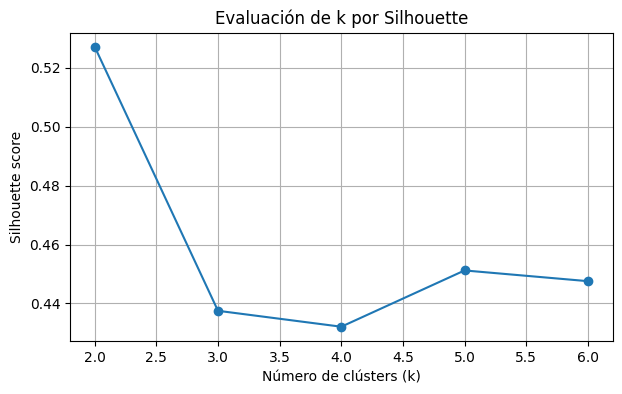

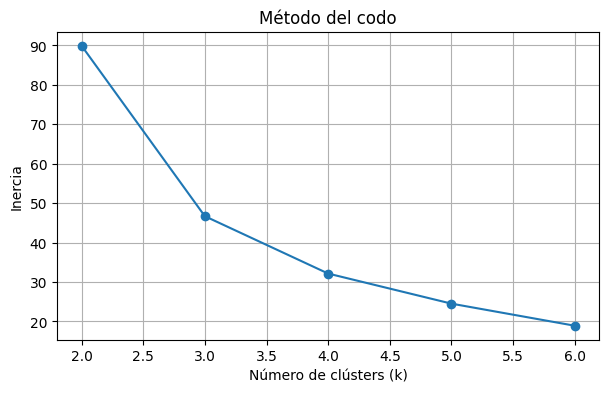

In [7]:
# Visualización: silhouette
plt.figure(figsize=(7, 4))
plt.plot(resultados_k["k"], resultados_k["silhouette"], marker="o")
plt.xlabel("Número de clústers (k)")
plt.ylabel("Silhouette score")
plt.title("Evaluación de k por Silhouette")
plt.grid(True)
plt.show()

# Visualización: inercia
plt.figure(figsize=(7, 4))
plt.plot(resultados_k["k"], resultados_k["inertia"], marker="o")
plt.xlabel("Número de clústers (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()


## 7. Entrenamiento final de KMeans y asignación de clústers

In [16]:
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_mun["cluster"] = kmeans_final.fit_predict(X_scaled)

# Reordenar etiquetas de clúster por temperatura media para hacerlas más interpretables
orden_clusters = (
    df_mun.groupby("cluster")["temp_mean_mean"]
    .mean()
    .sort_values()
    .index
    .tolist()
)
map_cluster = {old: new for new, old in enumerate(orden_clusters)}
df_mun["cluster"] = df_mun["cluster"].map(map_cluster)

print("Tamaño de clústers:")
print(df_mun["cluster"].value_counts().sort_index())

df_mun[["municipio", "cluster"] + vars_clima].sort_values(["cluster", "municipio"])


Tamaño de clústers:
cluster
0     2
1     9
2    11
3     3
Name: count, dtype: int64


,municipio,cluster,precip_mm_mean,temp_mean_mean,et_real_mm_mean,ndvi_mean_mean,balance_hidrico_mm_mean,MpAltitud
11,Marulanda,0,176.439803,13.164799,78.997560,0.584366,97.442244,2825.0
23,Villamaria,0,174.778242,11.170651,74.948648,0.447652,99.829594,1944.0
0,Aguadas,1,200.853095,17.591599,92.042603,0.698400,108.810493,2181.0
2,Aranzazu,1,170.304235,15.266344,85.919687,0.593390,84.384548,1908.0
7,Manizales,1,177.441572,15.573433,88.563947,0.628183,88.877625,2126.0
8,Manzanares,1,235.573441,17.166836,91.390058,0.659177,144.183383,2075.0
12,Neira,1,171.991462,15.799332,89.399425,0.640790,82.592037,1965.0
14,Pensilvania,1,249.633096,16.513404,87.262900,0.583420,162.370196,2100.0
15,Pácora,1,189.019380,17.089483,92.051722,0.671141,96.967658,1814.0
16,Riosucio,1,192.239183,15.780338,89.339764,0.656347,102.899419,1783.0


## 8. Caracterización de clústers

In [17]:
cluster_summary = df_mun.groupby("cluster")[vars_clima].agg(["mean", "std", "min", "max"])
cluster_summary


precip_mm_mean                                    temp_mean_mean  \
                  mean        std         min         max           mean   
cluster                                                                    
0           175.609023   1.174901  174.778242  176.439803      12.167725   
1           195.383127  28.965895  170.304235  249.633096      16.076125   
2           190.870579  11.126847  178.126433  211.876215      18.453310   
3           304.742640  16.458227  287.811546  320.683265      21.965855   

                                        et_real_mm_mean            ...  \
              std        min        max            mean       std  ...   
cluster                                                            ...   
0        1.410076  11.170651  13.164799       76.973104  2.863013  ...   
1        1.145292  13.904358  17.591599       88.910866  2.737638  ...   
2        0.644755  17.318127  19.461982       98.298315  0.742686  ...   
3        3.195314  18.977081  25.333863      101.668662  4.445716  ...   

        ndvi_mean_mean           balance_hidrico_mm_mean             \
                   min       max                    mean        std   
cluster                                                               
0             0.447652  0.584366               98.635919   1.688112   
1             0.583420  0.698400              106.472261  28.274883   
2             0.683236  0.758465               92.572264  11.006772   
3             0.682027  0.765860              203.073978  19.691456   

                                   MpAltitud                              
                min         max         mean         std     min     max  
cluster                                                                   
0         97.442244   99.829594  2384.500000  622.961074  1944.0  2825.0  
1         82.592037  162.370196  1971.666667  154.620503  1783.0  2181.0  
2         79.793231  114.100469  1491.090909  292.355419  1000.0  1800.0  
3        181.363635  219.781431  1066.666667  339.423531   675.0  1275.0  

[4 rows x 24 columns]

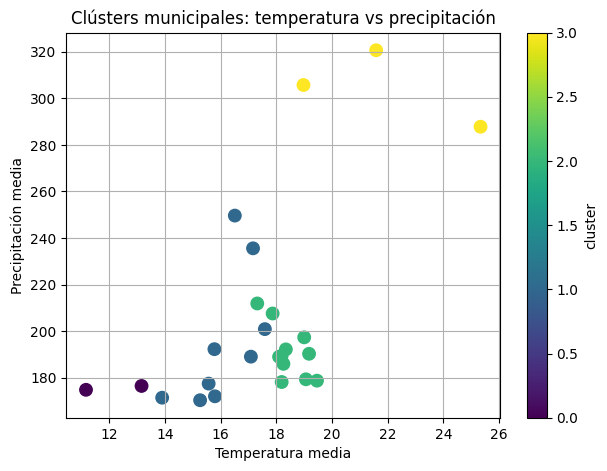

In [18]:
# Gráfico simple de separación climática
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df_mun["temp_mean_mean"],
    df_mun["precip_mm_mean"],
    c=df_mun["cluster"],
    s=80
)
plt.xlabel("Temperatura media")
plt.ylabel("Precipitación media")
plt.title("Clústers municipales: temperatura vs precipitación")
plt.grid(True)
plt.colorbar(scatter, label="cluster")
plt.show()


## 9. Guardar salidas

Se guardan dos archivos:

- `clusters_municipales.csv`: tabla limpia municipio-clúster.
- `features_intra_anuales_2007-2024_con_clusters.csv`: base de modelado con el clúster incorporado.


In [19]:
# Archivo principal de clústers
clusters_mun = df_mun[["municipio", "cluster"]].copy()
clusters_mun.to_csv(archivo_clusters, index=False)

# Base de modelado con clúster incorporado
# Evita duplicar columna cluster si ya existía
if "cluster" in df_model.columns:
    df_model = df_model.drop(columns=["cluster"])

df_model_cluster = df_model.merge(clusters_mun, on="municipio", how="left")

if df_model_cluster["cluster"].isna().sum() > 0:
    raise ValueError("Algunos registros de df_model no recibieron clúster. Revisa nombres de municipio.")

df_model_cluster.to_csv(archivo_features_cluster, index=False)

print("Archivo guardado:", archivo_clusters)
print("Archivo guardado:", archivo_features_cluster)
print("Registros clusters_mun:", clusters_mun.shape)
print("Registros df_model_cluster:", df_model_cluster.shape)


Archivo guardado: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/clusters_municipales.csv
Archivo guardado: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/features_intra_anuales_2007-2024_con_clusters.csv
Registros clusters_mun: (25, 2)
Registros df_model_cluster: (450, 505)


## 10. Validación final

In [20]:
# Leer archivos guardados para validar persistencia
clusters_check = pd.read_csv(archivo_clusters)
features_check = pd.read_csv(archivo_features_cluster)

print("clusters_municipales.csv")
print(clusters_check.head())
print("Municipios:", clusters_check["municipio"].nunique())
print("Distribución de clusters:")
print(clusters_check["cluster"].value_counts().sort_index())

print("features con clusters")
print(features_check[["municipio", "anio", "cluster"]].head())
print("Registros sin cluster:", features_check["cluster"].isna().sum())


clusters_municipales.csv
    municipio  cluster
0     Aguadas        1
1     Anserma        2
2    Aranzazu        1
3  Belalcázar        2
4   Chinchiná        2
Municipios: 25
Distribución de clusters:
cluster
0     2
1     9
2    11
3     3
Name: count, dtype: int64
features con clusters
    municipio  anio  cluster
0     Aguadas  2007        1
1     Anserma  2007        2
2    Aranzazu  2007        1
3  Belalcázar  2007        2
4   Chinchiná  2007        2
Registros sin cluster: 0
